# CS250 PROJECT 2 

## Xavier Hector & Kyle Moyo

### 
For our 2nd project we came across this <a href= "https://www.kaggle.com/datasets/laotse/credit-risk-dataset?resource=download"> Data</a> on kaggle and decided to use it. 

The goal of this project is to build and evaluate machine learning classification models that predict loan outcomes using a real-world credit dataset.

In order to do this we plan on using classifers such as: 
1. Logistic Regression
2. Decision Trees
3. Random Forest

which are implemented and compared to identify which model provides the best predictive performance.

These models are then evaluated using accuracy, precision, recall.

This project begins with some data cleaning and visualization, followed by model training, evaluation, and a discussion of the results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, mean_squared_error, r2_score

## Load Data

In [2]:
data = pd.read_csv("/Users/hecto129039/Downloads/credit_risk_dataset.csv")
data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## Data Explanation

| Feature Name                  | Description                                  | Type         |
|:------------------------------:|:--------------------------------------------:|:-----------:|
| person_age                     | Age                                          | Numeric     |
| person_income                  | Annual Income                                | Numeric     |
| person_home_ownership          | Home ownership                               | Categorical |
| person_emp_length              | Employment length (in years)                 | Numeric     |
| loan_intent                    | Loan intent                                  | Categorical |
| loan_grade                     | Loan grade                                   | Categorical |
| loan_amnt                      | Loan amount                                  | Numeric     |
| loan_int_rate                  | Interest rate                                | Numeric     |
| loan_status                    | Loan status (0 is denied, 1 is approved)     | Numeric     |
| loan_percent_income            | Percent income                               | Numeric     |
| cb_person_default_on_file      | Historical default                           | Categorical |
| cb_preson_cred_hist_length     | Credit history length                        | Numeric     |

## Clean + Encode

In [3]:
data.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [4]:
data.shape

(32581, 12)

In [5]:
data.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [6]:
data = data.dropna()

In [7]:
data.isna().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [8]:
data.shape

(28638, 12)

In [9]:
data = pd.get_dummies(data, drop_first=True) #converts categorical variables into a numerical format 

## Data Visualization 

### Loan Approval Distribution
The dataset is imbalanced, with approvals significantly less frequent than denials.

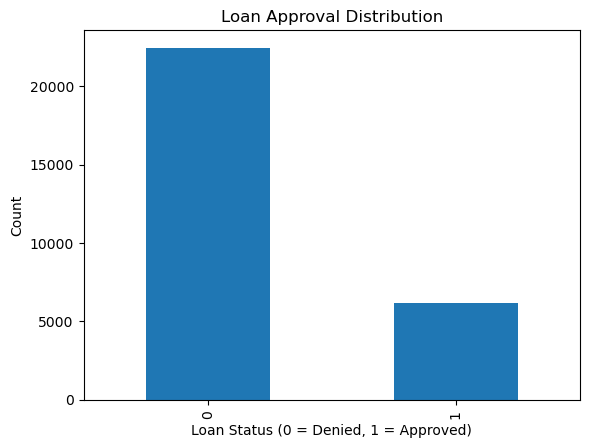

In [10]:
data["loan_status"].value_counts().plot(kind="bar")
plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status (0 = Denied, 1 = Approved)")
plt.ylabel("Count")
plt.show()

### Numeric Features 

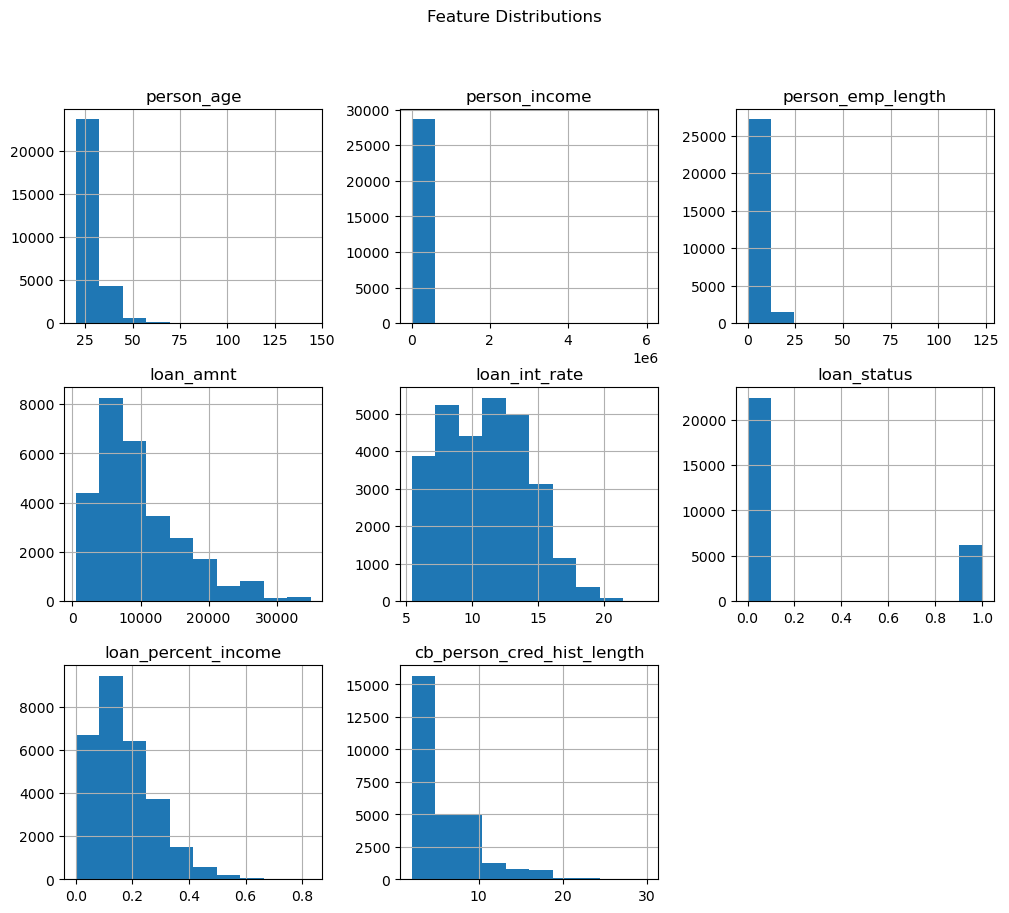

In [11]:
data.select_dtypes(include='number').hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

#### We realised that the person_income distribution graph looked falty and decided to look more into it.

In [12]:
data["person_income"].describe()

count    2.863800e+04
mean     6.664937e+04
std      6.235645e+04
min      4.000000e+03
25%      3.948000e+04
50%      5.595600e+04
75%      8.000000e+04
max      6.000000e+06
Name: person_income, dtype: float64

#### We then noticed that the max and min values were basically outliers which forced our barchat to stay closer to 0. Therefore we decided to apply a log scale to income however only for the visualization part of the project as we need the real income values in order to train our models. 

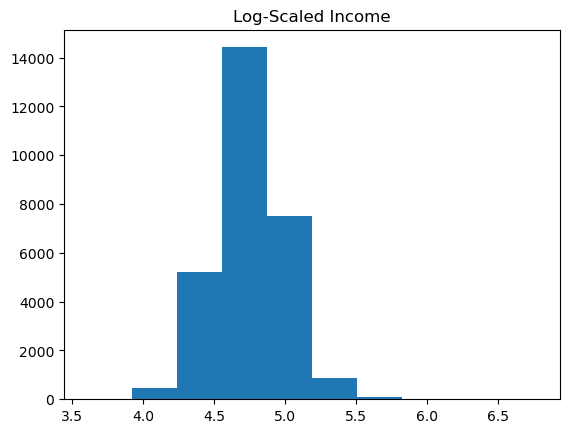

In [13]:
plt.hist(np.log10(data["person_income"] + 1))
plt.title("Log-Scaled Income")
plt.show()

### Correlation Heatmap

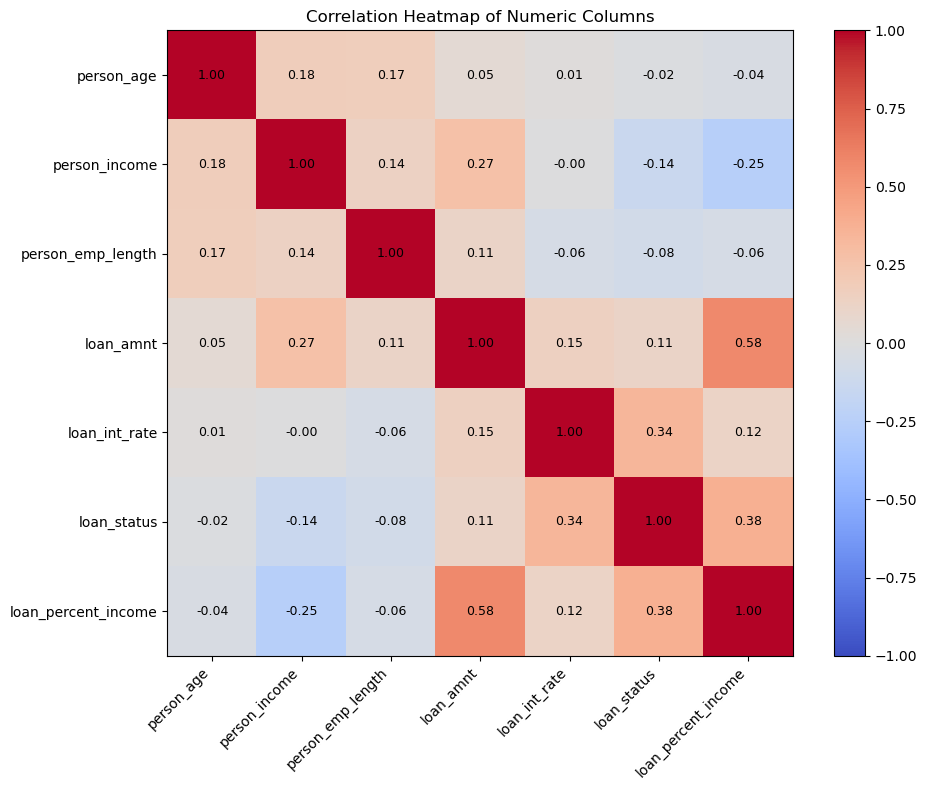

In [14]:
numeric_cols = [
    "person_age", 
    "person_income", 
    "person_emp_length", 
    "loan_amnt", 
    "loan_int_rate", 
    "loan_status", 
    "loan_percent_income", 
]

corr = data[numeric_cols].corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

# Add text labels (correlation values)
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", 
                 ha="center", va="center", color="black", fontsize=9)

plt.colorbar()
plt.title("Correlation Heatmap of Numeric Columns")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

### Loan Amount vs Approval

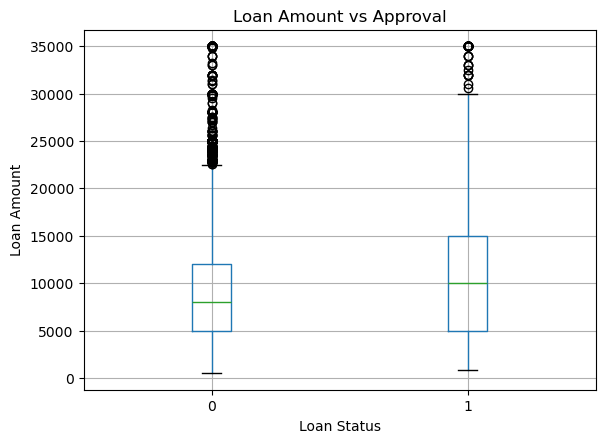

In [15]:
data.boxplot(column="loan_amnt", by="loan_status")
plt.title("Loan Amount vs Approval")
plt.suptitle("")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")
plt.show()

### Approval Rate by Employement

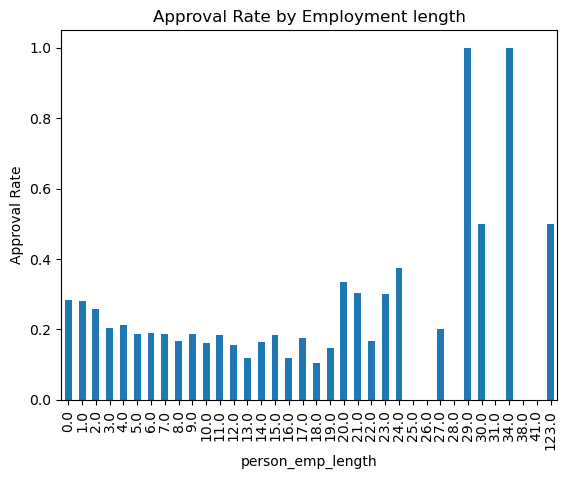

In [16]:
approval_rate = data.groupby("person_emp_length")["loan_status"].mean()

approval_rate.plot(kind="bar")
plt.title("Approval Rate by Employment length")
plt.ylabel("Approval Rate")
plt.show()

## Set Target

In [17]:
target = "loan_status"   
y = data[target]
X = data.drop(target, axis=1)

print(X.shape, y.shape)

(28638, 22) (28638,)


## Split Data 

In [18]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(22910, 22) (5728, 22) (22910,) (5728,)


## Scale Features

In [19]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Logistic Regression

In [20]:
log = LogisticRegression(max_iter=3000)
log.fit(X_train, y_train)

LogisticRegression(max_iter=3000)

In [21]:
y_pred = log.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8631284916201117
              precision    recall  f1-score   support

           0       0.88      0.95      0.92      4443
           1       0.78      0.55      0.64      1285

    accuracy                           0.86      5728
   macro avg       0.83      0.75      0.78      5728
weighted avg       0.86      0.86      0.85      5728



## Confusion Matrix Plot

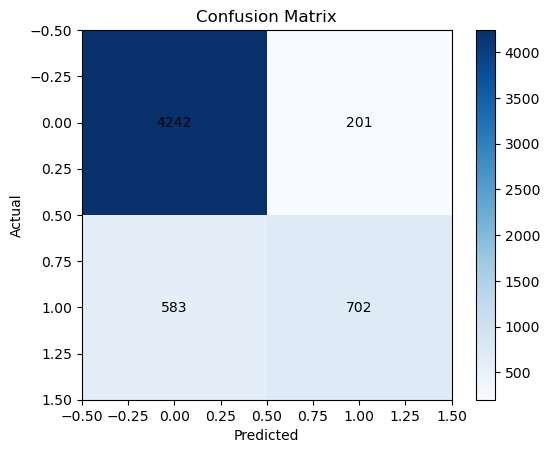

In [22]:
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(2):
    for j in range(2):
        plt.text(j,i,cm[i,j],ha="center",va="center")
plt.show()

| Value | Meaning                              |
|:-----:|:-------------------------------------:|
| 4242  | Correct denials                       |
| 702   | Correct approvals                     |
| 201   | Risky approvals (false positives)     |
| 583   | Missed approvals (false negatives)    |

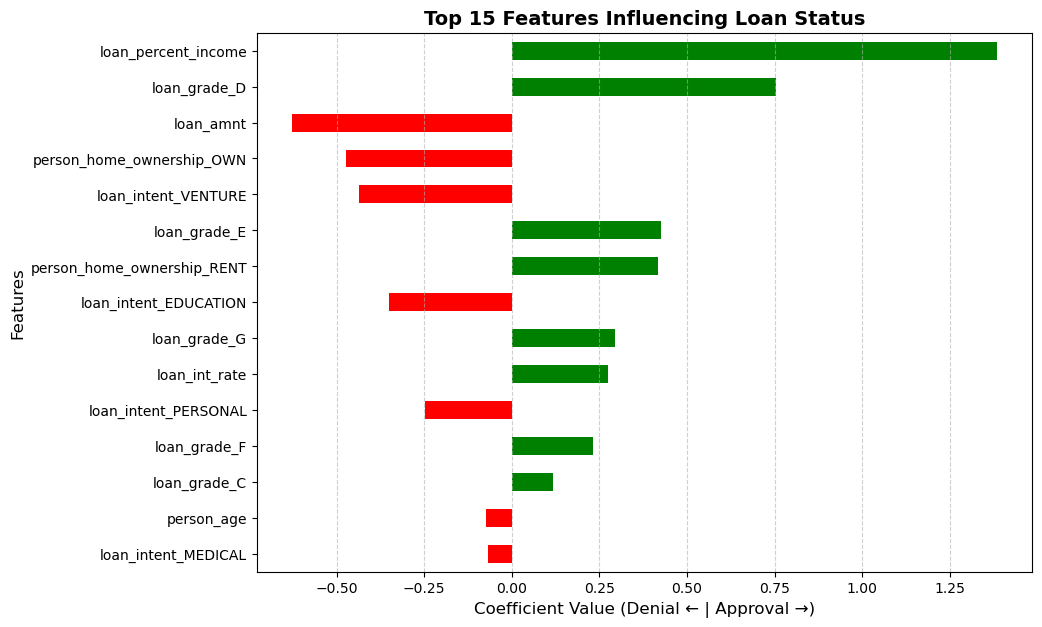

In [23]:
#Extract feature importance from Logistic Regression
importance = pd.Series(log.coef_[0], index=X.columns)

# Sort by strongest influence (absolute value first)
importance = importance.reindex(importance.abs().sort_values(ascending=False).index)

plt.figure(figsize=(10,7))

# Color logic: 
# Positive values → increase approval probability
# Negative values → decrease approval probability
colors = importance.apply(lambda x: 'green' if x > 0 else 'red')

# Plot top 15 features
importance.head(15).plot(kind='barh', color=colors.head(15))

plt.title("Top 15 Features Influencing Loan Status", fontsize=14, fontweight='bold')
plt.xlabel("Coefficient Value (Denial ← | Approval →)", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.gca().invert_yaxis()
plt.show()

In [24]:
grade_cols = [col for col in data.columns if col.startswith("loan_grade_")]

results = []

for col in grade_cols:
    subset = data[data[col] == 1]

    avg_rate = subset["loan_int_rate"].mean()
    approval_rate = subset["loan_status"].mean() * 100
    count = len(subset)

    results.append([col.replace("loan_grade_", ""), avg_rate, approval_rate, count])

summary = pd.DataFrame(results, columns=[
    "Loan Grade",
    "Avg Interest Rate",
    "Approval Rate (%)",
    "Count"
])

summary = summary.sort_values("Loan Grade")

print(summary)

  Loan Grade  Avg Interest Rate  Approval Rate (%)  Count
0          B          11.002471          15.878046   9151
1          C          13.453041          20.301807   5699
2          D          15.348901          59.205665   3248
3          E          17.005655          64.597701    870
4          F          18.597321          69.856459    209
5          G          20.251525          98.305085     59


## Decision Tree

In [25]:
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [26]:
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

In [27]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9038058659217877
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      4443
           1       0.95      0.60      0.74      1285

    accuracy                           0.90      5728
   macro avg       0.92      0.80      0.84      5728
weighted avg       0.91      0.90      0.90      5728



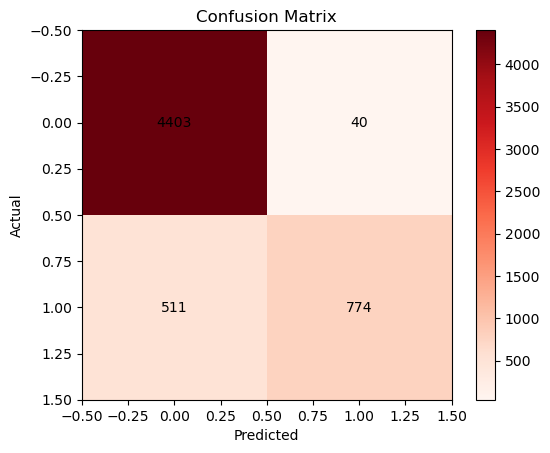

In [28]:
cm = confusion_matrix(y_test, y_pred_dt)
plt.imshow(cm, cmap='Reds')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(2):
    for j in range(2):
        plt.text(j,i,cm[i,j],ha="center",va="center")
plt.show()

| Value | Meaning                              |
|:-----:|:-------------------------------------:|
| 4403  | Correct denials                       |
| 774   | Correct approvals                     |
|  40 | Risky approvals (false positives)     |
| 511  | Missed approvals (false negatives)    |

## Random Forest

In [29]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [30]:
rf_pred = rf.predict(X_test)
print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

RF Accuracy: 0.9312150837988827
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4443
           1       0.96      0.72      0.82      1285

    accuracy                           0.93      5728
   macro avg       0.94      0.86      0.89      5728
weighted avg       0.93      0.93      0.93      5728



Random Forest recognizes complex financial patterns better than logistic regression and decision tree. It also produces fewer classification errors.

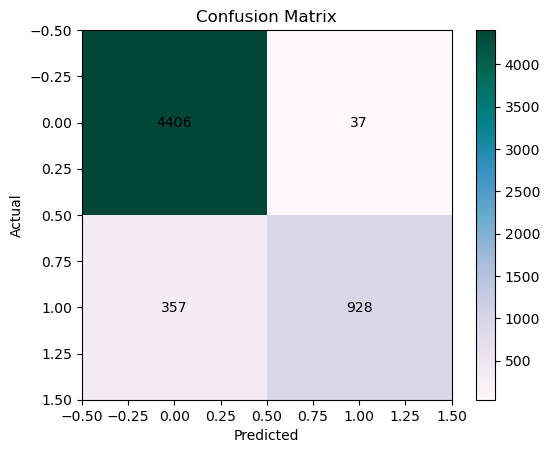

In [31]:
cm = confusion_matrix(y_test, rf_pred)
plt.imshow(cm, cmap='PuBuGn')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(2):
    for j in range(2):
        plt.text(j,i,cm[i,j],ha="center",va="center")
plt.show()

| Value | Meaning                              |
|:-----:|:-------------------------------------:|
| 4406  | Correct denials                       |
| 928   | Correct approvals                     |
|  37 | Risky approvals (false positives)     |
| 357  | Missed approvals (false negatives)    |

## Conclusion and Possible Improvements 

The models did a very good job at predicting the loan status. Ultimately, three classification models were evaluated to predict loan outcomes: Logistic Regression, Decision Tree, and Random Forest. The Random Forest model achieved the highest performance with an accuracy of 93.1%, outperforming both Logistic Regression (86.3% accuracy) and Decision Tree (90.4% accuracy). While Logistic Regression provided a strong baseline, it struggled to correctly identify loan approvals, whereas the Decision Tree improved prediction performance. Overall, the Random Forest model proved to be the most reliable, demonstrating its ability to capture complex patterns in financial data.

--------------------------


Although the models performed well, several improvements could be made. The dataset is imbalanced, which likely contributed to lower recall for approvals, and techniques such as resampling or class weighting could improve model fairness and performance. Additionally, hyperparameter tuning for the Decision Tree and Random Forest models could further increase accuracy.

_______

Furthermore, data visualization revealed data quality issues, including incorrect entries such as an employment length of 123 years, as well as the presence of outliers. These anomalies may have negatively impacted model performance. Implementing stricter data validation rules, removing unrealistic values, and applying outlier detection techniques could lead to more reliable results and improved model accuracy.